In [2]:
import datetime
import numpy as np
import pandas as pd
from concurrent.futures import ProcessPoolExecutor
from scipy.optimize import differential_evolution
import plotly.express as px
from tqdm import tqdm

from rocketpy import Environment, SolidMotor, Rocket, Flight
from rocketpy.simulation import FlightDataExporter
from rocketpy.utilities import apogee_by_mass, liftoff_speed_by_mass

import simplekml
import os

os.makedirs("../results", exist_ok=True)

print("Rocket Engineering Simulation System Initialized")

Rocket Engineering Simulation System Initialized



Gravity Details

Acceleration of gravity at surface level:    9.7913 m/s²
Acceleration of gravity at  80.000 km (ASL): 9.5534 m/s²


Launch Site Details

Launch Date: 2026-04-01 12:00:00 UTC
Launch Site Latitude: 32.99025°
Launch Site Longitude: -106.97500°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 315468.64 W    3651938.65 N
Launch Site UTM zone: 13S
Launch Site Surface Elevation: 1400.0 m


Atmospheric Model Details

Atmospheric Model Type: standard_atmosphere
standard_atmosphere Maximum Height: 80.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 0.00 m/s
Surface Wind Direction: 0.00°
Surface Wind Heading: 0.00°
Surface Pressure: 855.97 hPa
Surface Temperature: 279.07 K
Surface Air Density: 1.069 kg/m³
Surface Speed of Sound: 334.55 m/s


Earth Model Details

Earth Radius at Launch site: 6371.83 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



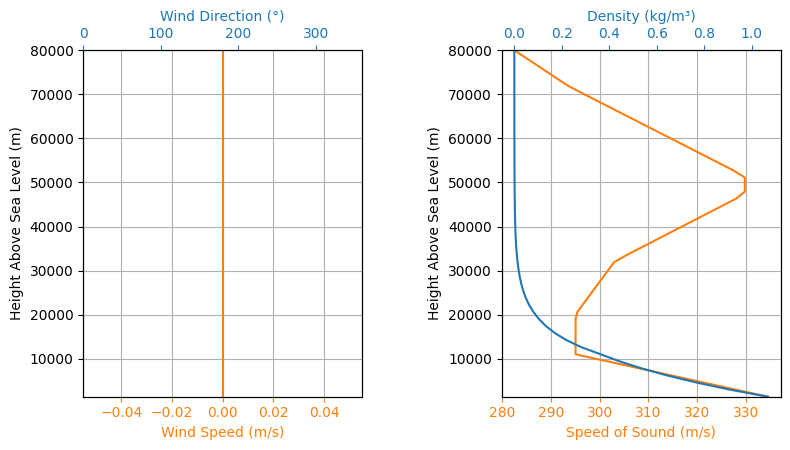

In [3]:
from rocketpy import Environment
import datetime

env = Environment(
    latitude=32.990254,
    longitude=-106.974998,
    elevation=1400
)

tomorrow = datetime.date.today() + datetime.timedelta(days=1)

env.set_date((tomorrow.year, tomorrow.month, tomorrow.day, 12))

# MODELO ATMOSFÉRICO RÁPIDO
env.set_atmospheric_model(type="standard_atmosphere")

env.info()

Nozzle Details
Nozzle Radius: 0.033 m
Nozzle Throat Radius: 0.011 m

Grain Details
Number of Grains: 5
Grain Spacing: 0.005 m
Grain Density: 1815 kg/m3
Grain Outer Radius: 0.033 m
Grain Inner Radius: 0.015 m
Grain Height: 0.12 m
Grain Volume: 0.000 m3
Grain Mass: 0.591 kg

Motor Details
Total Burning Time: 3.9 s
Total Propellant Mass: 2.956 kg
Structural Mass Ratio: 0.380
Average Propellant Exhaust Velocity: 339.775 m/s
Average Thrust: 257.524 N
Maximum Thrust: 832.1705 N at 1.44 s after ignition.
Total Impulse: 1004.345 Ns



c:\RocketWolf\rocket_env\Lib\site-packages\rocketpy\motors\motor.py:998: UserWarning: burn_time argument (0, 3.9) is out of thrust source time range. Using thrust_source boundary times instead: (0, 1.47) s.
If you want to change the burn out time of the curve please use the 'reshape_thrust_curve' argument.
  warnings.warn(


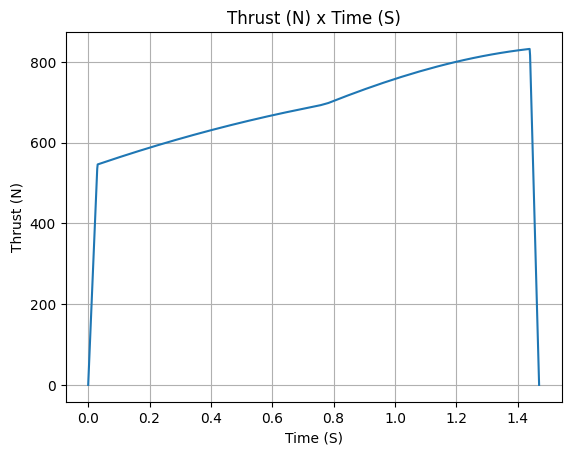

In [4]:
Honda_Felix = SolidMotor(
    thrust_source=r"C:\RocketWolf\data\motors\Honda_Felix.eng",
    dry_mass=1.815,
    dry_inertia=(0.125, 0.125, 0.002),
    nozzle_radius=0.033,
    grain_number=5,
    grain_density=1815,
    grain_outer_radius=0.033,
    grain_initial_inner_radius=0.015,
    grain_initial_height=0.12,
    grain_separation=0.005,
    grains_center_of_mass_position=0.397,
    center_of_dry_mass_position=0.317,
    nozzle_position=0,
    burn_time=3.9,
    throat_radius=0.011,
    coordinate_system_orientation="nozzle_to_combustion_chamber"
)

Honda_Felix.info()

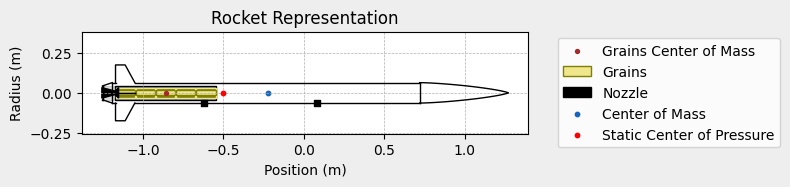

In [5]:
rocket = Rocket(
    radius=127/2000,
    mass=14.4,
    inertia=(6.321,6.321,0.034),
    power_off_drag=0.5,
    power_on_drag=0.6,
    center_of_mass_without_motor=0,
    coordinate_system_orientation="tail_to_nose"
)

rocket.add_motor(Honda_Felix, position=-1.255)

rocket.set_rail_buttons(
    upper_button_position=0.0818,
    lower_button_position=-0.6182,
    angular_position=45
)

rocket.add_nose(
    length=0.55,
    kind="vonkarman",
    position=1.27
)

rocket.add_trapezoidal_fins(
    n=4,
    root_chord=0.12,
    tip_chord=0.06,
    span=0.11,
    position=-1.05,
    cant_angle=0.5
)

rocket.add_tail(
    top_radius=0.0635,
    bottom_radius=0.0435,
    length=0.06,
    position=-1.19
)

rocket.draw()

In [6]:
flight = Flight(
    rocket=rocket,
    environment=env,
    rail_length=5.2,
    inclination=85,
    heading=0
)

flight.info()
flight.prints.maximum_values()


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 1400.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.923 | e1: -0.040 | e2: 0.017 | e3: 0.382
Euler Angles - Spin φ : 45.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.208 c


Surface Wind Conditions

Frontal Surface Wind Speed: 0.00 m/s
Lateral Surface Wind Speed: 0.00 m/s


Launch Rail

Launch Rail Length: 5.2 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.618 s
Rail Departure Velocity: 13.795 m/s
Rail Departure Stability Margin: 2.510 c
Rail Departure Angle of Attack: 0.000°
Rail Departure Thrust-Weight Ratio: 3.781
Rail Departure Reynolds Number: 1.074e+05


Burn out State

Burn out time: 3.900 s
Altitude at burn out: 1500.112 m (ASL) | 100.112 m (AGL)
Rocket speed at burn out: 18.458 m/s
Freestream velocit

In [7]:
exporter = FlightDataExporter(flight)

exporter.export_data("../results/full_flight_data.csv")

exporter.export_kml(
    file_name="../results/trajectory.kml",
    extrude=True,
    altitude_mode="relativetoground"
)

File  ../results/trajectory.kml  saved with success!


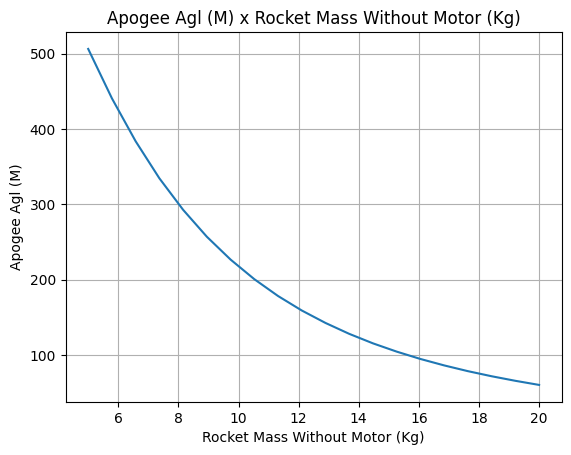

'Function from R1 to R1 : (Rocket Mass without motor (kg)) → (Apogee AGL (m))'

In [8]:
apogee_by_mass(
    flight=flight,
    min_mass=5,
    max_mass=20,
    points=20,
    plot=True
)

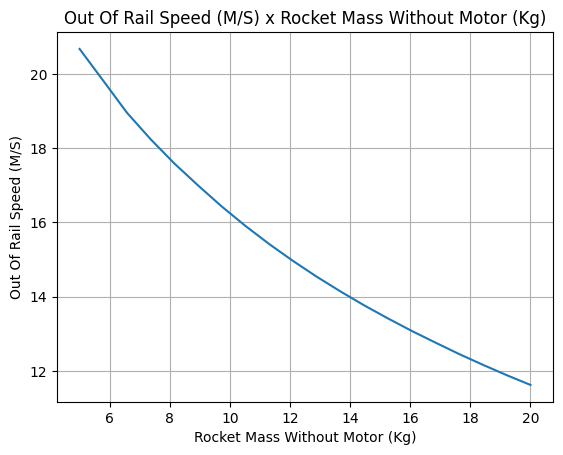

'Function from R1 to R1 : (Rocket Mass without motor (kg)) → (Out of Rail Speed (m/s))'

In [9]:
liftoff_speed_by_mass(
    flight=flight,
    min_mass=5,
    max_mass=20,
    points=20,
    plot=True
)

In [12]:
from concurrent.futures import ThreadPoolExecutor

N = 2000

with ThreadPoolExecutor(max_workers=10) as executor:
    results = list(tqdm(executor.map(run_sim, range(N)), total=N))

df = pd.DataFrame(results)
df.to_csv("../results/monte_carlo.csv", index=False)

print("Monte Carlo finalizado")
print("Arquivo salvo em /results")

NameError: name 'run_sim' is not defined

In [ ]:
print("Envelope de voo")

print("Apogeu máximo:", df.apogee.max())
print("Apogeu mínimo:", df.apogee.min())

In [ ]:
fig = px.scatter_3d(
    df,
    x="impact_x",
    y="impact_y",
    z="apogee",
    title="Flight Dispersion"
)

fig.show()

In [ ]:
def objective(x):

    mass, angle = x

    rocket.mass = mass

    f = Flight(
        rocket=rocket,
        environment=env,
        rail_length=5.2,
        inclination=angle,
        heading=0,
        terminate_on_apogee=True
    )

    return -f.apogee

bounds = [(10,20),(80,90)]

result = differential_evolution(objective, bounds)

print("Otimização:")
print(result.x)